In [3]:
import sys; sys.path.append('..') ## proejct root
from methods.config import *
import methods.genomics_util as genomics
import methods.shared as shared

import pickle
import numpy as np; rnd = np.random.default_rng()
import os
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
import Bio.SeqIO as SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation

with open(f'{pickled_dir}/barcode_clone_map.pkl', 'rb') as f:
    barcode_clone_map = pickle.load(f)

with open(f'{pickled_dir}/clone_barcode_map.pkl', 'rb') as f:
    clone_barcode_map = pickle.load(f)

with open(f'{pickled_dir}/mouse_clone_map.pkl', 'rb') as f:
    mouse_clone_map = pickle.load(f)

isolate_gd_dir = f'{data_dir}/isolate_wgs/E1_clones_gd_annotated'
gd_files = os.listdir(isolate_gd_dir)

ordered_barcodes = [(barcode, clones['all']) for barcode, clones in barcode_clone_map.items() if len(barcode) == 20]
ordered_barcodes.sort(key = lambda x:len(x[1]), reverse=True)

In [2]:
indexed_positions = []
day0_ids, LE1_ids, LE2_ids, other_ids, monoS1_mgx, monoS2_mgx, monoCOHOUSED_mgx, comm_mgx, MD_ids = [], [], [], [], [], [], [], [], []

coverage_array = []
with open(f'{data_dir}/BAM_coverages/BAM_coverages.txt', 'r') as f:
    header = next(f)

    ## id columns 
    header_ids = header.strip('\n').split('\t')[2:]
    for idx, id_str in enumerate(header_ids):
        if id_str.startswith('E1'): #MD sample
            MD_ids.append(idx)
        elif id_str == 'reference.bam': #day 0 metagenomic sample
            day0_ids.append(idx)
        elif 'iso' in id_str: #metagenomic sample
            iso = int(id_str.split('_')[0].replace('iso',''))
            mouse = int(id_str.split('_')[1].replace('m',''))
            if iso == 113 or iso == 116:
                comm_mgx.append(idx)
            if iso == 114:
                if mouse == 1:
                    monoS1_mgx.append(idx)
                if mouse == 2:
                    monoS2_mgx.append(idx)
                if mouse > 2:
                    monoCOHOUSED_mgx.append(idx)

        else:
            mouse = int(id_str.split('_')[0].replace('m',''))
            day = int(id_str.split('_')[1].replace('day',''))
            clone = int(id_str.split('_')[2].replace('c',''))
            barcode = clone_barcode_map[(mouse, day, clone)]
            if barcode in shared.LE1:
                LE1_ids.append(idx)
            elif barcode in shared.LE2:
                LE2_ids.append(idx)
            else:
                other_ids.append(idx)

    ## get coverage
    for line in f:
        line_items = line.strip('\n').split('\t')
        indexed_positions.append( int(line_items[1]) )
        coverage_array.append( [int(e) for e in line_items[2:]] )
        
indexed_positions = np.array(indexed_positions)
coverage_array = np.array(coverage_array).transpose()
normed_coverage_array = np.einsum('ij, i->ij', coverage_array, np.median(coverage_array, axis=1)**-1.)
ref_coverage = coverage_array[0] / np.median(coverage_array[0]) 

ValueError: invalid literal for int() with base 10: ' E1'

0 0.27232
573167 595424
0.27566666666666667 0.3356133333333333
595675 600171
0.1093 0.8741
4002186 4017482


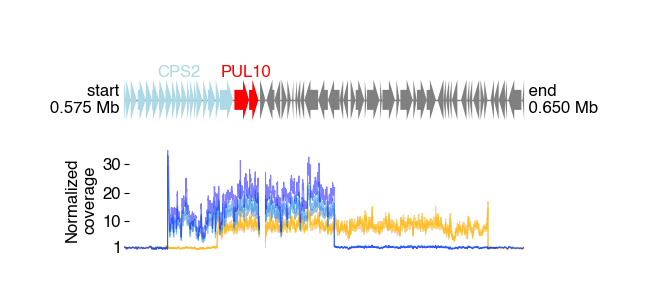

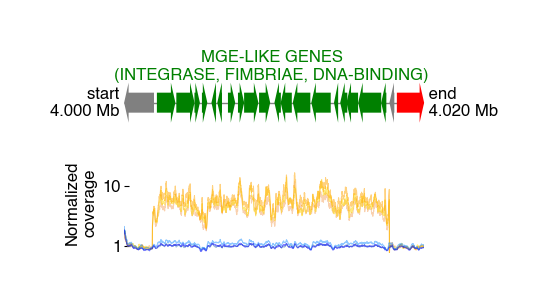

In [ ]:
mobile_element_genes = [f'BT{x}' for x in range(3135, 3154)]

def facecolor_handle_func(feature: SeqFeature) -> str:
    # Get gene name in GFF attributes column (e.g. `gene=araD;`)
    gene_name = feature.qualifiers.get("old_locus_tag", [""])[0]
    gene_descriptor = shared.gene_description[gene_name]
    # Set user-defined color based on gene name
    if gene_name in genomics.gene_PUL_map:
        return "red"
    # elif np.any([e in gene_descriptor for e in ['transposase', 'helix-turn-helix', 'mobilization']]):
    #     return "green"
    elif gene_name in mobile_element_genes:
        return "green"
    elif gene_name in genomics.gene_CPS_map:
        return "lightblue"
    else:
        return "grey"
    
def label_handle_func(gene_name) -> str:
    # Get gene name in GFF attributes column (e.g. `gene=araD;`)
    # gene_name = feature.qualifiers.get("old_locus_tag", [""])[0]
    # Set user-defined color based on gene name
    if gene_name == 'BT0479':
        return 'CPS 2 (BT0462-BT0482)'
    elif gene_name == 'BT0484':
        return 'PUL 10 (BT0483-BT0484)'
    else:
        return ''
        
def get_element_limits(element_name):
    if 'cps' in element_name:
        gene_lst = genomics.CPS_gene_map[element_name.split('\n')[0]]
        color = 'lightblue'
    elif 'PUL' in element_name:
        gene_lst = genomics.PUL_gene_map[int(element_name.split('\n')[0].split('PUL')[1])]
        color = 'red'
    elif 'MGE' in element_name:
        gene_lst = mobile_element_genes
        color = 'green'

    all_indices = np.ravel([[shared.gene_coords_map[gene][0], shared.gene_coords_map[gene][1]] for gene in gene_lst])
    return np.min(all_indices), np.max(all_indices), color

for label, start, end, operons, fig_width, max_cov in [('CPS2_PUL10', 575000, 650000, ['cps2', 'PUL10'], 4, 35), 
                          ('ME', 4000000, 4020000, ['MGE-like genes\n(integrase, fimbriae, DNA-binding)'], 3, 15)]:
    gv = GenomeViz(fig_width=fig_width)
    gbk = Genbank(f'{data_dir}/reference_genome/BtVPI-5482.gbk', min_range=start, max_range=end)
    track = gv.add_feature_track("", gbk.range_size, start_pos=gbk.min_range)

    track.add_genbank_features(gbk, size_ratio=0.4, allow_partial=True, facecolor_handle_func=facecolor_handle_func, 
                               label_type='', labelvpos='top')

    track.add_feature(start, start+1, label=f'start \n{start/10**6:.3f} Mb ', plotstyle='box', facecolor='none', 
                                linewidth=0, size_ratio=0, strand=1, labelha='right', labelvpos='center', labelrotation=0, labelsize=12)
    track.add_feature(end-1, end, label=f' end\n {end/10**6:.3f} Mb', plotstyle='box', facecolor='none', 
                                linewidth=0, size_ratio=0, strand=1, labelha='left', labelvpos='center', labelrotation=0, labelsize=12)     

    subtrack = gv.top_track.add_subtrack()
    fig = gv.plotfig()

    label_track = gv.top_track.ax 
    for element_name in operons[:]:
        element_start, element_end, element_color = get_element_limits(element_name)
        x1, x2 = max(0, (element_start-start) / (end-start)), min((element_end-start) / (end-start), 1)
        print(x1, x2)

        print(element_start, element_end)
        # label_track.axhline(0.5, xmin=x1, xmax=x2, color=element_color, linestyle='solid', lw=1.5, zorder=0)
        label_track.text((x1+x2)/2, 0.7, element_name.upper(), ha='center', va='bottom',color=element_color, fontsize=12, transform=label_track.transAxes)

    coverage_ax = gv.top_track.subtracks[0].ax
    
    for col, color in zip(LE1_ids, ['sandybrown', 'gold', 'orange']):
        coverage_ax.plot(indexed_positions, normed_coverage_array[col]/ref_coverage, color=color, alpha=0.5)
    for col, color in zip(LE2_ids, ['steelblue', 'dodgerblue', 'blue']):
        coverage_ax.plot(indexed_positions, normed_coverage_array[col]/ref_coverage, color=color, alpha=0.5)

    coverage_ax.yaxis.set_ticks_position('left')

    coverage_ax.set_ylim(0, max_cov)
    yticks = np.arange(0, (max_cov//10+1) * 10, 10, dtype=int)
    yticks[0] = 1
    coverage_ax.set_yticks(yticks)
    coverage_ax.set_yticklabels(yticks, fontsize=12)
    coverage_ax.set_ylabel('Normalized\ncoverage', fontsize=12)
    coverage_ax.set_xlim(start, end)


    # fig.savefig(f"{figures_dir}/{label}_genome_view.pdf", pad_inches=0.05)
    # fig.savefig(f"{figures_dir}/{label}_genome_view.pdf", pad_inches=0.05)
    # fig.savefig(f"{figures_dir}/{label}_genome_view.svg", pad_inches=0.05, format='svg')


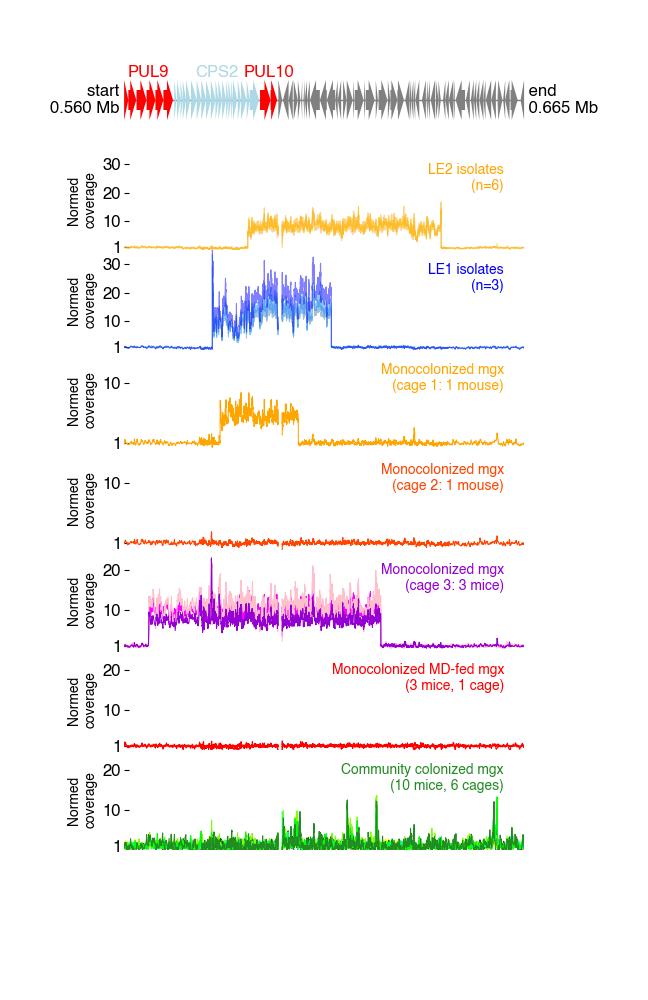

In [ ]:
def get_element_limits(element_name):
    if 'cps' in element_name:
        gene_lst = genomics.CPS_gene_map[element_name.split('\n')[0]]
        color = 'lightblue'
    elif 'PUL' in element_name:
        gene_lst = genomics.PUL_gene_map[int(element_name.split('\n')[0].split('PUL')[1])]
        color = 'red'
    elif '<GE' in element_name:
        gene_lst = mobile_element_genes
        color = 'green'

    all_indices = np.ravel([[shared.gene_coords_map[gene][0], shared.gene_coords_map[gene][1]] for gene in gene_lst])
    return np.min(all_indices), np.max(all_indices), color

mobile_element_genes = [f'BT{x}' for x in range(3135, 3154)]

for label, start, end, operons, fig_width in [('CPS2_PUL10', 560000, 665000, ['cps2', 'PUL10', 'PUL9'], 4)]: 
                         # ('ME', 4000000, 4020000, ['MOB-like genes\n(integrase, fimbriae, DNA-binding)'], 3)]:
    gv = GenomeViz(fig_width=fig_width)
    gbk = Genbank(f'{data_dir}/reference_genome/BtVPI-5482.gbk', min_range=start, max_range=end)
    track = gv.add_feature_track("", gbk.range_size, start_pos=gbk.min_range)

    track.add_genbank_features(gbk, size_ratio=0.4, allow_partial=True, facecolor_handle_func=facecolor_handle_func, 
                               label_type='', labelvpos='top')

    track.add_feature(start, start+1, label=f'start \n{start/10**6:.3f} Mb ', plotstyle='box', facecolor='none', 
                                linewidth=0, size_ratio=0, strand=1, labelha='right', labelvpos='center', labelrotation=0, labelsize=12)
    track.add_feature(end-1, end, label=f' end\n {end/10**6:.3f} Mb', plotstyle='box', facecolor='none', 
                                linewidth=0, size_ratio=0, strand=1, labelha='left', labelvpos='center', labelrotation=0, labelsize=12)     

    for i in range(8):
        subtrack = gv.top_track.add_subtrack()
    fig = gv.plotfig()

    label_track = gv.top_track.ax 
    for element_name in operons[:]:
        element_start, element_end, element_color = get_element_limits(element_name)
        x1, x2 = max(0, (element_start-start) / (end-start)), min((element_end-start) / (end-start), 1)
        # label_track.axhline(0.5, xmin=x1, xmax=x2, color=element_color, linestyle='solid', lw=1.5, zorder=0)
        label_track.text((x1+x2)/2, 0.7, element_name.upper(), ha='center', va='bottom',color=element_color, fontsize=12, transform=label_track.transAxes)

    ax1, ax2, ax3, ax4, ax5, ax6, ax7= [gv.top_track.subtracks[x].ax for x in range(0, 7)]
    # coverage_ax.plot([1+start,1000+start,3000+start], [0.5, 0.6, 5])
    
    for col, color in zip(LE1_ids, ['sandybrown', 'gold', 'orange']):
        ax1.plot(indexed_positions, normed_coverage_array[col]/ref_coverage, color=color, alpha=0.5)
    for col, color in zip(LE2_ids, ['steelblue', 'dodgerblue', 'blue']):
        ax2.plot(indexed_positions, normed_coverage_array[col]/ref_coverage, color=color, alpha=0.5)
    ax1.text(0.95, 0.6, 'LE2 isolates\n(n=6)', ha='right', transform=ax1.transAxes, color='orange')
    ax2.text(0.95, 0.6, 'LE1 isolates\n(n=3)', ha='right', transform=ax2.transAxes, color='blue')


    for ax, cols, colors, row_label in zip([ax3, ax4, ax5, ax6, ax7], 
                                        [monoS1_mgx, monoS2_mgx, monoCOHOUSED_mgx,  MD_ids, comm_mgx],
                                    #   [[14], [15], [16, 17, 18], [19, 20, 21, 22, 23]], 
                                      [['orange'], ['orangered'], ['fuchsia', 'pink', 'darkviolet'], ['red', 'red', 'red'], 
                                       ['olive', 'yellow', 'lawngreen', 'darkgreen', 'green', 'chartreuse','olivedrab', 'springgreen', 'lime', 'forestgreen'], ],
                                      ['Monocolonized mgx\n(cage 1: 1 mouse)', 'Monocolonized mgx\n(cage 2: 1 mouse)', 'Monocolonized mgx\n(cage 3: 3 mice)', 'Monocolonized MD-fed mgx\n(3 mice, 1 cage)', 'Community colonized mgx\n(10 mice, 6 cages)']):
        for i, col in enumerate(cols): 
            ax.plot(indexed_positions, normed_coverage_array[col]/ref_coverage, color=colors[i], alpha=1)
        ax.text(0.95, 0.6, row_label, ha='right', transform=ax.transAxes, color=colors[-1])

    for ax, max_cov in zip([ax1, ax2, ax3, ax4, ax5, ax6, ax7], [35, 35, 15, 15, 25, 25, 25]):
        ax.yaxis.set_ticks_position('left')
        ax.set_ylim(0, max_cov)
        yticks = np.arange(0, (max_cov//10+1) * 10, 10, dtype=int)
        yticks[0] = 1
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks, fontsize=12)
        ax.set_ylabel('Normed\ncoverage', fontsize=10)
        ax.set_xlim(start, end)

    # fig.savefig(f"{figures_dir}/{label}_genome_view_E1_and_E2.pdf", pad_inches=0.05, dpi=300, transparent=True)
    plt.rcParams['svg.fonttype'] = 'none'
    fig.savefig(f"{figures_dir}/{label}_genome_view_E1_and_E2.pdf", pad_inches=0.05, transparent=True)
    fig.savefig(f"{figures_dir}/{label}_genome_view.svg", pad_inches=0.05, format='svg', transparent=True)


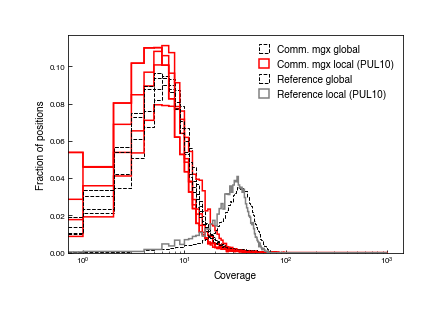

In [ ]:
## Sanity check: does lack of coverage, and/or mismapped skewing coverage to other species, explain absence of amplification in co-colonization condition?
## No, local region around cps2 and PUL10 has same coverage distribution as globally (~10X)
## so no problem where e.g. local coverage << global coverage due to mismappings at other regions of genome, and thus no observed amplifications.

local_region_start, local_region_end = 560000, 665000
sub_indices = np.where((indexed_positions >= local_region_start) & (indexed_positions <= local_region_end))[0]

fig, ax = plt.subplots()
# for ids, color, label in [(mono_mgx, 'blue', 'mono. mgx'), (comm_mgx, 'red', 'comm.')]:
for ids, color, label in [(comm_mgx, 'red', 'Comm. mgx'), ([0], 'grey', 'Reference'),]:
    global_label = label + ' global'
    local_label = label + ' local (PUL10)'
    for col in ids:
        ax.hist(coverage_array[col], bins=np.linspace(0, 100, 101), histtype='step', color='k', density=True, label=global_label, linewidth=1, ls='dashed')
        ax.hist(coverage_array[col][sub_indices], bins=np.linspace(0, 1000, 1001), histtype='step', color=color, density=True, label=local_label, linewidth=1.5)
        global_label, local_label = '', ''
ax.legend(loc=1, fontsize=10)
ax.set_xlabel('Coverage')
ax.set_ylabel('Fraction of positions')
ax.set_xscale('log')